In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
(x_train,y_train), (x_test,y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


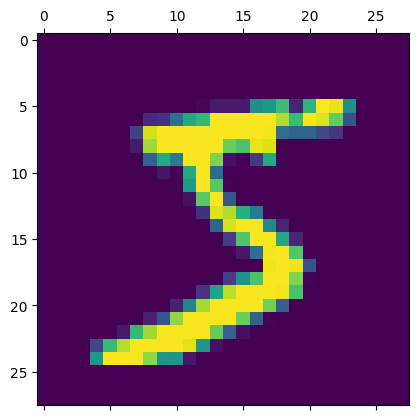

In [ ]:
plt.matshow(x_train[0])

In [ ]:
# normalize the data(0-1) # [0-255]------> [0 - 1]

x_train = x_train/255.0
x_test = x_test/255.0

In [ ]:
# reshape, include the channels  RGB--->Grey Scales
x_train = x_train.reshape(-1,28,28,1)  # -1---len(x_train)
x_test = x_test.reshape(-1,28,28,1)

#Building the model

**Create a Sequential model**

models.Sequential([...])
A simple stack of layers, where the output of one is the input to the next.

**Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))**

Learns 32 filters (feature detectors), each 3×3, scanning the image.

**input_shape=(28,28,1) says “28×28 pixels, 1 channel (grayscale)”.**

relu turns negative values to 0, helping the network learn non-linear patterns.

Output shape: 26×26×32 (because 28−3+1 = 26 with valid padding).

**MaxPooling2D((2,2))**

Takes the max in each 2×2 window, downsampling to reduce size and overfitting; adds a bit of translation invariance.

Output shape: 13×13×32.

**Conv2D(64, (3,3), activation='relu')**

Another conv layer with 64 filters to learn more complex patterns from the previous feature maps.

Output shape: 11×11×64 (13−3+1 = 11).

**MaxPooling2D((2,2))**

Downsamples again.

Output shape: 5×5×64 (floor of 11/2).

**Flatten()**

Converts the 3D tensor to a 1D vector so it can go into fully connected layers.

Output shape: 5×5×64 = 1600 units.

**Dense(64, activation='relu')**

A fully connected layer that mixes all features and learns non-linear combinations.

Output shape: 64.

**Dense(10, activation='softmax')**

Final classification layer for 10 classes.

softmax outputs a probability distribution that sums to 1.

Output shape: 10 (one probability per class).

In [ ]:
# Build the CNN model
model = models.Sequential([ layers.Conv2D(32,(3,3),activation = 'relu',input_shape = (28,28,1)),
                           layers.MaxPooling2D((2,2)),
                           layers.Conv2D(64,(3,3),activation='relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Flatten(),
                           layers.Dense(64,activation='relu'),
                           layers.Dense(10,activation='softmax')])

# compile the model
model.compile(optimizer ='adam', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'] )

In [ ]:
# Training
model.fit(x_train, y_train,epochs = 5, validation_data=(x_test,y_test))
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f'Test accuracy: {test_acc: .4f}')

In [ ]:
x_test[5]

In [ ]:
# loading an image
from PIL import Image

In [ ]:
Image.open('/content/imgof3.png')

In [ ]:
img = Image.open('/content/imgof3.png').convert('L') # convert to gray scale

In [ ]:
img = img.resize((28,28))

In [ ]:
import numpy as np
img_array = np.array(img)

In [ ]:
img_array

In [ ]:
img_array = img_array - 255

In [ ]:
img_array = img_array/255

In [ ]:
input_data = img_array.reshape(1,28,28,1)  #--grey scale

In [ ]:
model.predict(input_data)

In [ ]:
pred = model.predict(input_data)
np.argmax(pred)

In [ ]:
img = Image.open('/content/imgof7.png').convert('L') # convert to gray scale
img = img.resize((28,28))  #Resizes to 28×28, the input size expected by your CNN.
import numpy as np

'''Converts the PIL image into a NumPy array of pixel values.
Now shape is (28, 28).
Values range from 0 (black) to 255 (white).'''


img_array = np.array(img)

# scale pixels to [0,1] by dividing by 255.

#img_array = 255 - img_array   # invert colors
img_array= img_array - 255
img_array = img_array / 255.0



''' Reshapes from (28,28) → (1,28,28,1).
1 = batch size (predicting one image).
28,28 = image dimensions.
1 = grayscale channel.
This matches the model’s input shape.'''

input_data = img_array.reshape(1,28,28,1)  #--grey scale

pred = model.predict(input_data)

'''Model outputs probabilities for each of the 10 classes (digits 0–9).
pred.shape = (1,10) → 1 row (one image), 10 columns (one probability per class).'''

np.argmax(pred)

#'''argmax returns the index of the largest probability.If the 3rd element is highest, it returns 2.That’s the predicted digit'''

#Image → resize → grayscale → normalize → reshape → CNN → probability distribution → pick max → predicted digit.